In [8]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from qdots_qll.distributions import (
    _ESS,
    _ESSlog,
    logDistribution,
    normalize_log_weights,
)

In [10]:
from tensorflow_probability.substrates import jax as tfp


In [11]:
seed = 0
key = jax.random.PRNGKey(seed=seed)
key, subkey = jax.random.split(key)

loc = jnp.array([1, 2.3])
scale = jnp.array([0.4, 0.2])

In [12]:
truncatednormdist = tfp.distributions.TruncatedNormal(
    loc=loc, scale=scale, low=jnp.array([0.3, 0.4]), high=jnp.array([3.0, 7.0])
)

In [14]:
no_particles = 100
particles_locations = truncatednormdist.sample(
    seed=subkey, sample_shape=(no_particles,)
)
weights = jnp.ones(no_particles) / 100

ldist = logDistribution(particles_locations=particles_locations, weights=weights)
# nd = tfp.distributions.MultivariateNormalFullCovariance(
#     loc=loc, covariance_matrix=jnp.diag(scale)
# )
# another_pars_locs = nd.sample(seed=subkey, sample_shape=(no_particles,))

In [21]:
ldist

logDistribution(
  no_rv=2,
  no_particles=100,
  particles_locations=f32[100,2],
  weights=f32[100]
)

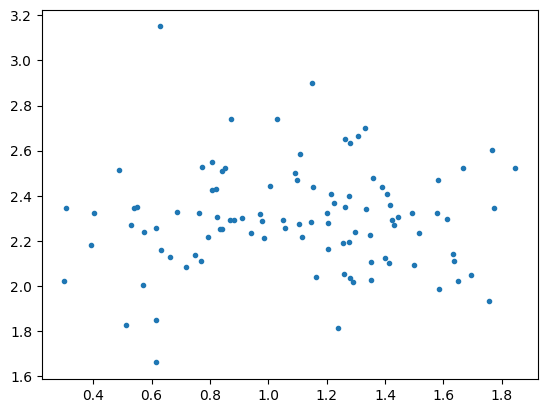

In [22]:
import matplotlib.pyplot as plt

plt.plot(ldist.particles_locations[:, 0], ldist.particles_locations[:, 1], ".")

In [103]:
from qdots_qll.distributions import Distribution


dis = Distribution(particles_locations=particles_locations, weights=weights)

In [120]:
key = jax.random.key(seed = seed)
key, subkey = jax.random.split(key)